In [36]:
!pip install pygraphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.0/106.0 kB 8.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for pygraphviz (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pygraphviz
Failed to build pygraphviz
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pygraphviz)


In [37]:
import pandas as pd
import numpy as np
from scipy import stats

import dowhy
from dowhy import CausalModel

In [38]:
data_df = pd.read_csv("/content/Students Social Media Addiction.csv")

data_df.drop(columns=['Avg_Daily_Usage_Hours', "Student_ID"], inplace=True)
data_df.head()

,Age,Gender,Academic_Level,Country,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,Female,Undergraduate,Bangladesh,Instagram,Yes,6.5,6,In Relationship,3,8
1,22,Male,Graduate,India,Twitter,No,7.5,8,Single,0,3
2,20,Female,Undergraduate,USA,TikTok,Yes,5.0,5,Complicated,4,9
3,18,Male,High School,UK,YouTube,No,7.0,7,Single,1,4
4,21,Male,Graduate,Canada,Facebook,Yes,6.0,6,In Relationship,2,7


In [39]:
# Codificación de variables categóricas
data_df['Gender'] = data_df['Gender'].map({'Male': 0, 'Female': 1})

level_mapping = {'High School': 0, 'Bachelors': 1, 'Masters': 2, 'PhD': 3}
data_df['Academic_Level'] = data_df['Academic_Level'].map(level_mapping)

In [40]:
nodes = []

for nodo in data_df.columns:
  nodes.append(nodo)

edges = [
    ('Country','Most_Used_Platform'),
    ('Country','Mental_Health_Score'),
    ('Age', 'Mental_Health_Score'),
    ('Age', 'Most_Used_Platform'),
    ('Most_Used_Platform', 'Addicted_Score'),
    ('Most_Used_Platform', 'Conflicts_Over_Social_Media'),
    ('Age', 'Addicted_Score'),
    ('Age', 'Conflicts_Over_Social_Media'),
    ('Addicted_Score', 'Mental_Health_Score'),
    ('Conflicts_Over_Social_Media', 'Mental_Health_Score'),
    ('Addicted_Score', 'Sleep_Hours_Per_Night'),
    ('Addicted_Score', 'Affects_Academic_Performance'),
    ('Sleep_Hours_Per_Night', 'Mental_Health_Score'),
    ('Sleep_Hours_Per_Night', 'Affects_Academic_Performance'),
    ('Affects_Academic_Performance', 'Mental_Health_Score'),
    ('Relationship_Status', 'Mental_Health_Score'),

]

gml_graph = """
graph [
    directed 1

    node [
        id "Country"
        label "Country"
    ]
    node [
        id "Most_Used_Platform"
        label "Most_Used_Platform"
    ]
    node [
        id "Mental_Health_Score"
        label "Mental_Health_Score"
    ]
    node [
        id "Age"
        label "Age"
    ]
    node [
        id "Addicted_Score"
        label "Addicted_Score"
    ]
    node [
        id "Conflicts_Over_Social_Media"
        label "Conflicts_Over_Social_Media"
    ]
    node [
        id "Sleep_Hours_Per_Night"
        label "Sleep_Hours_Per_Night"
    ]

    node [
        id "Affects_Academic_Performance"
        label "Affects_Academic_Performance"
    ]
    node [
        id "Relationship_Status"
        label "Relationship_Status"
    ]
    node [
        id "Gender"
        label "Gender"
    ]
    node[
        id "Academic_Level"
        label "Academic_Level"
    ]

    edge [
        source "Country"
        target "Most_Used_Platform"
    ]
    edge [
        source "Country"
        target "Mental_Health_Score"
    ]
    edge [
        source "Age"
        target "Most_Used_Platform"
    ]
    edge [
        source "Most_Used_Platform"
        target "Addicted_Score"
    ]
    edge [
        source "Most_Used_Platform"
        target "Conflicts_Over_Social_Media"
    ]
    edge [
        source "Age"
        target "Addicted_Score"
    ]
    edge [
        source "Age"
        target "Conflicts_Over_Social_Media"
    ]
    edge [
        source "Addicted_Score"
        target "Mental_Health_Score"
    ]
    edge [
        source "Conflicts_Over_Social_Media"
        target "Mental_Health_Score"
    ]
    edge [
        source "Addicted_Score"
        target "Sleep_Hours_Per_Night"
    ]
    edge [
        source "Addicted_Score"
        target "Affects_Academic_Performance"
    ]
    edge [
        source "Sleep_Hours_Per_Night"
        target "Mental_Health_Score"
    ]
    edge [
        source "Age"
        target "Mental_Health_Score"
    ]
    edge [
        source "Relationship_Status"
        target "Mental_Health_Score"
    ]
    edge [
        source "Relationship_Status"
        target "Affects_Academic_Performance"
    ]
    edge [
        source "Affects_Academic_Performance"
        target "Mental_Health_Score"
    ]
    edge [
        source "Gender"
        target "Addicted_Score"
    ]
    edge[
        source "Academic_Level"
        target "Addicted_Score"
    ]


]
"""


In [41]:
# Empiezo probando Sleep_Hours_Per_Night:

model = CausalModel( # Modelo donde la variable de tratamiento son las horas de sueño
    data=data_df,
    treatment='Sleep_Hours_Per_Night',
    outcome='Mental_Health_Score',
    graph=gml_graph
)

AttributeError: `np.alltrue` was removed in the NumPy 2.0 release. Use `np.all` instead.

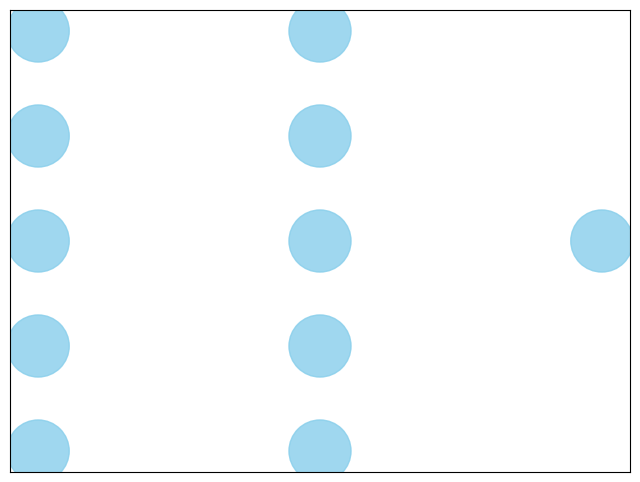

In [42]:
model.view_model() # El error acá posiblemente se deba a una incorrecta instalación de pygraphviz,
# Pero no afecta a la data, solo a la visualización


In [43]:
estimand = model.identify_effect()
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
           d                                                   
────────────────────────(E[Mental_Health_Score|Addicted_Score])
d[Sleep_Hours_Per_Night]                                       
Estimand assumption 1, Unconfoundedness: If U→{Sleep_Hours_Per_Night} and U→Mental_Health_Score then P(Mental_Health_Score|Sleep_Hours_Per_Night,Addicted_Score,U) = P(Mental_Health_Score|Sleep_Hours_Per_Night,Addicted_Score)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



In [24]:
model = CausalModel(
    data=data_df,
    treatment='Addicted_Score',
    outcome='Mental_Health_Score',
    graph=gml_graph
)

In [25]:
estimand = model.identify_effect()
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                       
─────────────────(E[Mental_Health_Score|Most_Used_Platform,Age])
d[Addicted_Score]                                               
Estimand assumption 1, Unconfoundedness: If U→{Addicted_Score} and U→Mental_Health_Score then P(Mental_Health_Score|Addicted_Score,Most_Used_Platform,Age,U) = P(Mental_Health_Score|Addicted_Score,Most_Used_Platform,Age)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                                             ↪
 ⎢            d                                  ⎛            d                ↪
E⎢─────────────────────────(Mental_Health_Score)⋅⎜─────────────────────────([A ↪
 ⎣d[Gender  Academic_Level]                      ⎝d[Gender  Academic_Level]    ↪

↪                 -1⎤
↪                ⎞  ⎥
↪ ddicted_Score])⎟  ⎥
↪                ⎠  ⎦
Estima

In [26]:
estimate_iv = model.estimate_effect(
    identified_estimand=estimand,
    method_name='iv'
)
print(f'Estimate of causal effect (IV method): {estimate_iv.value}')

IndexError: list index out of range

In [27]:
model = CausalModel(
    data=data_df,
    treatment='Addicted_Score',
    outcome='Mental_Health_Score',
    graph=gml_graph
)

estimand = model.identify_effect()
print(estimand)

try:
    estimate_backdoor = model.estimate_effect( # En esta parte se calcula estimadamente el efecto que tiene addicted
                                              # score sobre la salud mental
        identified_estimand=estimand,
        method_name='backdoor.linear_regression',

    )
    print(f'\nEstimate of causal effect (backdoor, linear regression): {estimate_backdoor.value}')
except Exception as e:
    print(f"\nError during backdoor estimation: {e}")

try:
    estimate_iv = model.estimate_effect(
        identified_estimand=estimand,
        method_name='iv.instrumental_variable',

    )
    print(f'\nEstimate of causal effect (IV method): {estimate_iv.value}')
except Exception as e:
    print(f"\nError during IV estimation: {e}")

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                       
─────────────────(E[Mental_Health_Score|Most_Used_Platform,Age])
d[Addicted_Score]                                               
Estimand assumption 1, Unconfoundedness: If U→{Addicted_Score} and U→Mental_Health_Score then P(Mental_Health_Score|Addicted_Score,Most_Used_Platform,Age,U) = P(Mental_Health_Score|Addicted_Score,Most_Used_Platform,Age)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                                             ↪
 ⎢            d                                  ⎛            d                ↪
E⎢─────────────────────────(Mental_Health_Score)⋅⎜─────────────────────────([A ↪
 ⎣d[Gender  Academic_Level]                      ⎝d[Gender  Academic_Level]    ↪

↪                 -1⎤
↪                ⎞  ⎥
↪ ddicted_Score])⎟  ⎥
↪                ⎠  ⎦
Estima

/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimator.py:266: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_effect_mods = data.groupby(effect_modifier_names)
/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behav


Estimate of causal effect (backdoor, linear regression): -0.6344391964838962

Error during IV estimation: exog contains inf or nans


/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFra

In [29]:
refutation = model.refute_estimate( # Parte del codigo donde se refuta o aprueba el valor estimado
    estimand=estimand,
    estimate=estimate_backdoor,
    method_name='random_common_cause'
)
print(refutation)

/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimator.py:266: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_effect_mods = data.groupby(effect_modifier_names)
/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behav

Refute: Add a random common cause
Estimated effect:-0.6344391964838962
New effect:-0.6344391964838962
p value:1.0



/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/usr/local/lib/python3.11/dist-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFra

Por lo tanto, como no hubo modificaciones en la estimación del efecto, el efecto de la variable Addicted_Score sobre Mental_Health_Score es -0.6344